# Lung CV Model — Tier 1 (multi-label texture classifier)

Fine-tunes the USCL ResNet-18 backbone (ultrasound-domain pretrained, already in hand) as a
**multi-label** classifier for the 4 texture-based pathologies visible in a single frame:
B-lines, consolidation (the sonographic sign of pneumonia), pleural effusion, pleural thickening.

Multi-label (independent sigmoid per class), not softmax, because these findings co-occur
clinically (e.g. consolidation + effusion together) — softmax would wrongly force them to
compete for probability mass.

Pneumothorax is deliberately **not** in this notebook — it's a motion pattern invisible in a
single frame, handled separately by a classical motion feature per the Models-Registry plan.

**Before running**: upload `Pulmonary/` (specifically `POCUS_extracted/` and `USCL_weights/`)
and `manifests/pulmonary_manifest.csv` to your Google Drive, preserving this relative structure,
e.g. under `MyDrive/POCUS-Project/`. Adjust `DRIVE_ROOT` in the config cell if your path differs.


## 1. Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q opencv-python-headless imageio scikit-learn down


Mounted at /content/drive
  Preparing metadata (setup.py) ... done


In [8]:
import io
import json
import zipfile
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

DRIVE_ROOT = Path('/content/drive/MyDrive/POCUS-Project')
MANIFEST_PATH = DRIVE_ROOT / 'manifests' / 'pulmonary_manifest.csv'
DATA_ROOT = DRIVE_ROOT / 'Pulmonary' / 'POCUS_extracted'
USCL_CKPT = DRIVE_ROOT / 'Pulmonary' / 'USCL_weights' / 'checkpoint' / 'best_model.pth'

FINDING_COLS = ['finding_b_lines', 'finding_consolidation', 'finding_pleural_effusion', 'finding_pleural_thickening']
FRAMES_PER_CLIP = 8
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 25
LR = 1e-3

# 3-candidate lung bake-off (see Models-Registry.md) -- run this notebook once per value of
# BACKBONE and compare AUROC/F1. USFM's weights ARE verified downloadable (checked directly
# against the USFM GitHub repo's own config + loading code), unlike UltraSam for cardiac.
BACKBONE = 'uscl'  # 'uscl' | 'imagenet' | 'usfm'

# USFM checkpoint: hosted on Google Drive by the paper's authors (CC-BY-NC 4.0 -- non-commercial,
# fine for this internship). Downloaded once via gdown, then cached in Drive so it isn't
# re-fetched every session.
USFM_GDRIVE_ID = '1KRwXZgYterH895Z8EpXpR1L1eSMMJo4q'
USFM_CKPT = DRIVE_ROOT / 'Pulmonary' / 'USFM_weights' / 'USFM_latest.pth'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)


Device: cuda


In [9]:
!ls /content/drive/MyDrive/

'1-1-Ancien Examen.gdoc'
 Admission.pdf
 AMl
'archive (5).zip'
 binary_results.csv
 breast
 breastCancer
"Capture d'écran 2026-03-10 202544.png"
'Capture d'\''écran 2026-03-10 221837 (1).png'
"Capture d'écran 2026-03-10 221837.png"
'Capture d'\''écran 2026-03-10 221845 (1).png'
"Capture d'écran 2026-03-10 221845.png"
'Capture d'\''écran 2026-03-10 221853 (1).png'
"Capture d'écran 2026-03-10 221853.png"
'certif (1).pdf'
'certif (2).pdf'
 certif.pdf
'certifs (1).pdf'
'certifs (2).pdf'
 certifs.pdf
 clmsCertificate-data1.pdf
'Colab Notebooks'
 commercialvideo.mp4
'Cover Letter.pdf'
'CV Video.mp4'
 data.csv
 demo_breast_cancer.mp4
 demo.mp4
 DOSSIER-SPONSORING-Action-Couffin-du-Ramadan-2-1.pdf
'Grey Minimalist Ramadan Greeting Poster.pdf'
 Icones
 inbound2571823640434721799.png
'Koffet_Ramadan_2026_Needs_FINAL (1).xlsx'
'Koffet_Ramadan_2026_Needs_FINAL (2).xlsx'
'Koffet_Ramadan_2026_Needs_FINAL (3).xlsx'
 Koffet_Ramadan_2026_Needs_FINAL.gsheet
 Koffet_Ramadan_2026_Needs_FINAL.xlsx
'

## 2. Load and filter the manifest

Drops rows already flagged by the manifest itself (`flag_do_not_use`, `flag_off_target_organ`),
and builds the multi-label target array from the 4 finding columns.


In [10]:
df = pd.read_csv(MANIFEST_PATH)
df = df[~df['flag_do_not_use'] & ~df['flag_off_target_organ']].reset_index(drop=True)
df['filepath'] = df['filepath'].str.replace('\\\\', '/', regex=True)
df['labels'] = df[FINDING_COLS].astype(int).values.tolist()

print(f'{len(df)} clips/images after filtering')
print(df[FINDING_COLS].sum())


187 clips/images after filtering
finding_b_lines               63
finding_consolidation         60
finding_pleural_effusion      24
finding_pleural_thickening    46
dtype: int64


## 3. Train/val split — by clip, not by frame

Splitting after frame extraction would leak frames from the same clip into both train and val
(they're near-duplicates). Split the 198 clips first, stratified on the original disease `class`
column as a reasonable proxy for balancing the finding labels too (true multi-label stratification
is overkill at this sample size).


In [ ]:
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['class']
)
print(f'Train clips: {len(train_df)}, Val clips: {len(val_df)}')



Train clips: 149, Val clips: 38


## 4. Frame extraction

Videos are a mix of mp4/avi/mov/mpeg (OpenCV) and gif (OpenCV can't read these — falls back to
imageio). Images pass through as a single frame. Samples `FRAMES_PER_CLIP` evenly spaced frames
per clip — nearby frames in an ultrasound clip are near-identical for a texture-based task, so
more than ~8 buys little.


In [12]:
def extract_frames(filepath: Path, media_type: str, n_frames: int) -> list:
    if media_type == 'image':
        return [np.array(Image.open(filepath).convert('RGB'))]

    suffix = filepath.suffix.lower()
    if suffix == '.gif':
        frames = imageio.mimread(str(filepath))
        frames = [np.array(Image.fromarray(f).convert('RGB')) for f in frames]
    else:
        cap = cv2.VideoCapture(str(filepath))
        frames = []
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        cap.release()

    if not frames:
        return []
    idx = np.linspace(0, len(frames) - 1, min(n_frames, len(frames))).astype(int)
    return [frames[i] for i in idx]


## 5. Dataset

Materializes every sampled frame up front (the whole dataset is small enough that this is
simpler and faster than lazy per-item decoding).


In [13]:
class LungMultiLabelDataset(Dataset):
    def __init__(self, manifest_df: pd.DataFrame, transform):
        self.transform = transform
        self.samples = []
        for _, row in manifest_df.iterrows():
            filepath = DATA_ROOT / row['filepath']
            if not filepath.exists():
                print('Missing file, skipping:', filepath)
                continue
            frames = extract_frames(filepath, row['media_type'], FRAMES_PER_CLIP)
            label = np.array(row['labels'], dtype=np.float32)
            for frame in frames:
                self.samples.append((frame, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame, label = self.samples[idx]
        image = self.transform(Image.fromarray(frame))
        return image, torch.from_numpy(label)


# Normalization has to match what each backbone was actually pretrained with: USCL used
# mean/std=0.5/0.25 (not ImageNet stats), while a real torchvision ImageNet checkpoint expects
# ImageNet's own mean/std. USFM's exact stats aren't documented anywhere confirmable -- ImageNet
# stats used as a reasonable default, worth revisiting if USFM underperforms suspiciously.
NORM_STATS = {
    'uscl': ([0.5, 0.5, 0.5], [0.25, 0.25, 0.25]),
    'imagenet': ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    'usfm': ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
}


def make_transforms(norm_mean, norm_std):
    train_transform = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0), ratio=(0.8, 1.25)),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize(mean=norm_mean, std=norm_std),
    ])
    val_transform = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=norm_mean, std=norm_std),
    ])
    return train_transform, val_transform


# Frame decoding (the slow part) happens once here, with a placeholder transform. Each backbone
# loop iteration below swaps .transform in place via build_dataloaders() instead of re-decoding.
_placeholder_train_t, _placeholder_val_t = make_transforms(*NORM_STATS['imagenet'])
train_dataset = LungMultiLabelDataset(train_df, _placeholder_train_t)
val_dataset = LungMultiLabelDataset(val_df, _placeholder_val_t)
print(f'Train frames: {len(train_dataset)}, Val frames: {len(val_dataset)}')


def build_dataloaders(backbone_name):
    train_transform, val_transform = make_transforms(*NORM_STATS[backbone_name])
    train_dataset.transform = train_transform
    val_dataset.transform = val_transform
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
    return train_loader, val_loader


Train frames: 954, Val frames: 227


## 6. Backbone — USCL (Candidate 1), ImageNet (Candidate 2), or USFM ViT-B (Candidate 3)

`ResNetUSCL` is copied from the USCL repo's own `resnet_uscl.py`. Per the checkpoint's own eval
recipe: discard the `linear`/`fc` keys when loading (trained for USCL's contrastive pretext task,
not our 4-label problem) — keep only the `features.*` backbone weights.

ImageNet is torchvision's standard pretrained ResNet-18 — the actual baseline needed to honestly
quantify the domain-pretraining gap on *our* task, rather than trusting the original paper's number.

**USFM (Candidate 3)** is a real ViT-B/16 pretrained on 2M+ multi-organ ultrasound images
(openmedlab/USFM, CC-BY-NC 4.0). Its full repo depends on mmengine/mmseg/Hydra for the
*segmentation* path, but the *classification* path (`build_vit`) doesn't need any of that — the
`VisionTransformer` class below is copied directly from `usdsgen/modules/backbone/vision_transformer.py`,
and the exact architecture hyperparameters (patch_size=16, embed_dim=768, depth=12, num_heads=12,
relative position bias, no absolute position embedding) come straight from the repo's own
`configs/model/Cls/vit.yaml` — not guessed. The `remap_pretrained_keys_vit` function (also copied,
from `usdsgen/utils/modelutils.py`) handles expanding the checkpoint's shared relative-position-bias
into per-layer ones and interpolating it if our input resolution differs from pretraining.

Caveat flagged honestly: the exact input normalization stats USFM was pretrained with aren't
explicitly documented anywhere I could confirm — using ImageNet stats as a reasonable default,
noted in the code as an assumption worth revisiting if USFM underperforms suspiciously.

Below, `build_model(backbone_name)` builds whichever one you ask for. Section 9 calls it once per
candidate in a loop, so this whole notebook trains and compares all three in a single run.


In [14]:
import math
from functools import partial

import numpy as np
from scipy.interpolate import RegularGridInterpolator as RGI
from timm.models.layers import DropPath, to_2tuple, trunc_normal_


# --- Everything below is copied from openmedlab/USFM's usdsgen/modules/backbone/vision_transformer.py
# and usdsgen/utils/modelutils.py (classification path only -- no mmseg/Hydra dependency needed) ---

class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.0):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, qk_scale=None, attn_drop=0.0, proj_drop=0.0,
                 window_size=None, attn_head_dim=None):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        if attn_head_dim is not None:
            head_dim = attn_head_dim
        all_head_dim = head_dim * self.num_heads
        self.scale = qk_scale or head_dim ** -0.5

        self.qkv = nn.Linear(dim, all_head_dim * 3, bias=False)
        if qkv_bias:
            self.q_bias = nn.Parameter(torch.zeros(all_head_dim))
            self.v_bias = nn.Parameter(torch.zeros(all_head_dim))
        else:
            self.q_bias = None
            self.v_bias = None

        if window_size:
            self.window_size = window_size
            self.num_relative_distance = (2 * window_size[0] - 1) * (2 * window_size[1] - 1) + 3
            self.relative_position_bias_table = nn.Parameter(torch.zeros(self.num_relative_distance, num_heads))
            coords_h = torch.arange(window_size[0])
            coords_w = torch.arange(window_size[1])
            coords = torch.stack(torch.meshgrid([coords_h, coords_w]))
            coords_flatten = torch.flatten(coords, 1)
            relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
            relative_coords = relative_coords.permute(1, 2, 0).contiguous()
            relative_coords[:, :, 0] += window_size[0] - 1
            relative_coords[:, :, 1] += window_size[1] - 1
            relative_coords[:, :, 0] *= 2 * window_size[1] - 1
            relative_position_index = torch.zeros(size=(window_size[0] * window_size[1] + 1,) * 2, dtype=relative_coords.dtype)
            relative_position_index[1:, 1:] = relative_coords.sum(-1)
            relative_position_index[0, 0:] = self.num_relative_distance - 3
            relative_position_index[0:, 0] = self.num_relative_distance - 2
            relative_position_index[0, 0] = self.num_relative_distance - 1
            self.register_buffer("relative_position_index", relative_position_index)
        else:
            self.window_size = None
            self.relative_position_bias_table = None
            self.relative_position_index = None

        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(all_head_dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x, rel_pos_bias=None):
        B, N, C = x.shape
        qkv_bias = None
        if self.q_bias is not None:
            qkv_bias = torch.cat((self.q_bias, torch.zeros_like(self.v_bias, requires_grad=False), self.v_bias))
        qkv = F.linear(input=x, weight=self.qkv.weight, bias=qkv_bias)
        qkv = qkv.reshape(B, N, 3, self.num_heads, -1).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        q = q * self.scale
        attn = q @ k.transpose(-2, -1)

        if self.relative_position_bias_table is not None:
            relative_position_bias = self.relative_position_bias_table[self.relative_position_index.view(-1)].view(
                self.window_size[0] * self.window_size[1] + 1, self.window_size[0] * self.window_size[1] + 1, -1)
            relative_position_bias = relative_position_bias.permute(2, 0, 1).contiguous()
            attn = attn + relative_position_bias.unsqueeze(0)
        if rel_pos_bias is not None:
            attn = attn + rel_pos_bias

        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, -1)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, qkv_bias=False, qk_scale=None, drop=0.0, attn_drop=0.0,
                 drop_path=0.0, init_values=None, act_layer=nn.GELU, norm_layer=nn.LayerNorm,
                 window_size=None, attn_head_dim=None):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias, qk_scale=qk_scale,
                               attn_drop=attn_drop, proj_drop=drop, window_size=window_size, attn_head_dim=attn_head_dim)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)

        if init_values is not None:
            self.gamma_1 = nn.Parameter(init_values * torch.ones(dim), requires_grad=True)
            self.gamma_2 = nn.Parameter(init_values * torch.ones(dim), requires_grad=True)
        else:
            self.gamma_1, self.gamma_2 = None, None

    def forward(self, x, rel_pos_bias=None):
        if self.gamma_1 is None:
            x = x + self.drop_path(self.attn(self.norm1(x), rel_pos_bias=rel_pos_bias))
            x = x + self.drop_path(self.mlp(self.norm2(x)))
        else:
            x = x + self.drop_path(self.gamma_1 * self.attn(self.norm1(x), rel_pos_bias=rel_pos_bias))
            x = x + self.drop_path(self.gamma_2 * self.mlp(self.norm2(x)))
        return x


class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)
        num_patches = (img_size[1] // patch_size[1]) * (img_size[0] // patch_size[0])
        self.patch_shape = (img_size[0] // patch_size[0], img_size[1] // patch_size[1])
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = num_patches
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x, **kwargs):
        B, C, H, W = x.shape
        assert H == self.img_size[0] and W == self.img_size[1], \
            f"Input image size ({H}*{W}) doesn't match model ({self.img_size[0]}*{self.img_size[1]})."
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x


class VisionTransformer(nn.Module):
    """BEiT-style ViT, copied from USFM's vision_transformer.py (VisionTransformer with support for
    relative position bias, no absolute position embedding -- matches configs/model/Cls/vit.yaml)."""

    def __init__(self, img_size=224, patch_size=16, in_chans=3, num_classes=1000, embed_dim=768, depth=12,
                 num_heads=12, mlp_ratio=4.0, qkv_bias=False, qk_scale=None, drop_rate=0.0, attn_drop_rate=0.0,
                 drop_path_rate=0.0, norm_layer=nn.LayerNorm, init_values=None, use_abs_pos_emb=True,
                 use_rel_pos_bias=False, use_shared_rel_pos_bias=False, use_mean_pooling=True,
                 init_scale=0.001, **kwargs):
        super().__init__()
        self.num_classes = num_classes
        self.num_features = self.embed_dim = embed_dim
        self.patch_size = patch_size
        self.in_chans = in_chans
        self.patch_embed = PatchEmbed(img_size=img_size, patch_size=patch_size, in_chans=in_chans, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim)) if use_abs_pos_emb else None
        self.pos_drop = nn.Dropout(p=drop_rate)

        self.rel_pos_bias = None  # use_shared_rel_pos_bias=False in USFM's Cls config -- per-layer bias instead
        self.use_rel_pos_bias = use_rel_pos_bias

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            Block(dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, qkv_bias=qkv_bias, qk_scale=qk_scale,
                  drop=drop_rate, attn_drop=attn_drop_rate, drop_path=dpr[i], norm_layer=norm_layer,
                  init_values=init_values, window_size=self.patch_embed.patch_shape if use_rel_pos_bias else None)
            for i in range(depth)
        ])
        self.norm = nn.Identity() if use_mean_pooling else norm_layer(embed_dim)
        self.fc_norm = norm_layer(embed_dim) if use_mean_pooling else None
        self.head = nn.Linear(embed_dim, num_classes) if num_classes > 0 else nn.Identity()

        if self.pos_embed is not None:
            trunc_normal_(self.pos_embed, std=0.02)
        trunc_normal_(self.cls_token, std=0.02)
        if num_classes > 0:
            trunc_normal_(self.head.weight, std=0.02)
        self.apply(self._init_weights)
        self._fix_init_weight()
        if num_classes > 0:
            self.head.weight.data.mul_(init_scale)
            self.head.bias.data.mul_(init_scale)

    def _fix_init_weight(self):
        for layer_id, layer in enumerate(self.blocks):
            layer.attn.proj.weight.data.div_(math.sqrt(2.0 * (layer_id + 1)))
            layer.mlp.fc2.weight.data.div_(math.sqrt(2.0 * (layer_id + 1)))

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def get_num_layers(self):
        return len(self.blocks)

    def forward_features(self, x):
        x = self.patch_embed(x)
        batch_size, seq_len, _ = x.size()
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        if self.pos_embed is not None:
            x = x + self.pos_embed
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x, rel_pos_bias=None)
        x = self.norm(x)
        if self.fc_norm is not None:
            t = x[:, 1:, :]
            return self.fc_norm(t.mean(1))
        return x[:, 0]

    def forward(self, x):
        return self.head(self.forward_features(x))


def remap_pretrained_keys_vit(model, checkpoint_model):
    """Copied from USFM's modelutils.py -- expands the checkpoint's shared relative position bias
    into one per layer, and interpolates it if our input resolution differs from pretraining."""
    num_layers = model.get_num_layers()
    if "rel_pos_bias.relative_position_bias_table" in checkpoint_model:
        rel_pos_bias = checkpoint_model["rel_pos_bias.relative_position_bias_table"]
        for i in range(num_layers):
            checkpoint_model[f"blocks.{i}.attn.relative_position_bias_table"] = rel_pos_bias.clone()
        checkpoint_model.pop("rel_pos_bias.relative_position_bias_table")

    all_keys = list(checkpoint_model.keys())
    for key in all_keys:
        if "relative_position_index" in key:
            checkpoint_model.pop(key)
        if "relative_position_bias_table" in key and key in model.state_dict():
            rel_pos_bias = checkpoint_model[key]
            src_num_pos, num_attn_heads = rel_pos_bias.size()
            dst_num_pos, _ = model.state_dict()[key].size()
            if src_num_pos == dst_num_pos:
                continue
            dst_patch_shape = model.patch_embed.patch_shape
            num_extra_tokens = dst_num_pos - (dst_patch_shape[0] * 2 - 1) * (dst_patch_shape[1] * 2 - 1)
            src_size = int((src_num_pos - num_extra_tokens) ** 0.5)
            dst_size = int((dst_num_pos - num_extra_tokens) ** 0.5)
            print(f'Position interpolate for {key} from {src_size}x{src_size} to {dst_size}x{dst_size}')
            extra_tokens = rel_pos_bias[-num_extra_tokens:, :]
            rel_pos_bias = rel_pos_bias[:-num_extra_tokens, :]

            def geometric_progression(a, r, n):
                return a * (1.0 - r ** n) / (1.0 - r)

            left, right = 1.01, 1.5
            while right - left > 1e-6:
                q = (left + right) / 2.0
                gp = geometric_progression(1, q, src_size // 2)
                right, left = (q, left) if gp > dst_size // 2 else (right, q)
            dis = []
            cur = 1
            for i in range(src_size // 2):
                dis.append(cur)
                cur += q ** (i + 1)
            r_ids = [-_ for _ in reversed(dis)]
            x = r_ids + [0] + dis
            y = r_ids + [0] + dis
            t = dst_size // 2.0
            dx = np.arange(-t, t + 0.1, 1.0)
            dy = np.arange(-t, t + 0.1, 1.0)
            xi, yi = np.meshgrid(dx, dy, indexing="ij")
            points = np.array([xi.ravel(), yi.ravel()]).T
            all_rel_pos_bias = []
            for i in range(num_attn_heads):
                z = rel_pos_bias[:, i].view(src_size, src_size).float().numpy()
                f = RGI((x, y), z.T, method="cubic", bounds_error=False)
                all_rel_pos_bias.append(torch.Tensor(f(points).reshape(xi.shape)).contiguous().view(-1, 1))
            rel_pos_bias = torch.cat(all_rel_pos_bias, dim=-1)
            checkpoint_model[key] = torch.cat((rel_pos_bias, extra_tokens), dim=0)
    return checkpoint_model


class USFMFeatureExtractor(nn.Module):
    """Thin wrapper so USFM's ViT plugs into the same feature_extractor(x) -> (B, num_ftrs)
    interface as the ResNet backbones, matching what LungFindingClassifier expects."""
    def __init__(self, vit: VisionTransformer):
        super().__init__()
        self.vit = vit

    def forward(self, x):
        return self.vit.forward_features(x)


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [15]:
class ResNetUSCL(nn.Module):
    def __init__(self, base_model='resnet18', out_dim=256):
        super().__init__()
        resnet = models.resnet18(weights=None)
        num_ftrs = resnet.fc.in_features
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        self.linear = nn.Linear(num_ftrs, out_dim)


class LungFindingClassifier(nn.Module):
    def __init__(self, feature_extractor: nn.Module, num_ftrs: int, num_labels: int):
        super().__init__()
        self.features = feature_extractor
        self.head = nn.Linear(num_ftrs, num_labels)

    def forward(self, x):
        h = self.features(x)
        h = h.flatten(1)
        return self.head(h)


def build_model(backbone_name):
    if backbone_name == 'uscl':
        backbone = ResNetUSCL(base_model='resnet18', out_dim=256)
        state_dict = torch.load(USCL_CKPT, map_location='cpu')
        backbone_dict = {k: v for k, v in state_dict.items() if not (k.startswith('l') or k.startswith('fc'))}
        missing, unexpected = backbone.load_state_dict(backbone_dict, strict=False)
        print('Missing keys:', missing)
        print('Unexpected keys:', unexpected)
        feature_extractor = backbone.features
        num_ftrs = backbone.linear.in_features
        # Fine-tune recipe matching the paper's own validated approach: freeze everything except
        # the last residual block. Applied identically across all 3 backbones for a fair comparison.
        unfreeze_marker = 'features.7.1'

    elif backbone_name == 'imagenet':
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        num_ftrs = resnet.fc.in_features
        feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
        unfreeze_marker = '7.1'  # same "last residual block" position, different naming since this isn't wrapped in .features

    elif backbone_name == 'usfm':
        if not USFM_CKPT.exists():
            USFM_CKPT.parent.mkdir(parents=True, exist_ok=True)
            import gdown
            gdown.download(id=USFM_GDRIVE_ID, output=str(USFM_CKPT), quiet=False)
        # Exact hyperparameters from USFM's own configs/model/Cls/vit.yaml -- not guessed.
        vit = VisionTransformer(
            img_size=IMG_SIZE, patch_size=16, in_chans=3, num_classes=0,  # num_classes=0 -> just the pooled embedding, no head
            embed_dim=768, depth=12, num_heads=12, mlp_ratio=4.0, qkv_bias=True,
            attn_drop_rate=0.0, drop_path_rate=0.1, init_values=0.1,
            use_abs_pos_emb=False, use_rel_pos_bias=True, use_shared_rel_pos_bias=False, use_mean_pooling=True,
        )
        checkpoint = torch.load(USFM_CKPT, map_location='cpu')
        checkpoint = checkpoint.get('model', checkpoint)  # some checkpoints wrap the state_dict under a 'model' key
        checkpoint = remap_pretrained_keys_vit(vit, checkpoint)
        missing, unexpected = vit.load_state_dict(checkpoint, strict=False)
        print('Missing keys:', missing)
        print('Unexpected keys:', unexpected)
        feature_extractor = USFMFeatureExtractor(vit)
        num_ftrs = 768
        unfreeze_marker = 'blocks.11'  # last of the 12 transformer blocks -- same "last stage" freeze philosophy

    else:
        raise ValueError(f'Unknown backbone: {backbone_name}')

    model = LungFindingClassifier(feature_extractor, num_ftrs, num_labels=len(FINDING_COLS)).to(device)

    # Same freeze strategy for every backbone -- last block/stage + new head trainable, everything
    # else frozen. Keeping this identical across candidates is what makes the bake-off comparison fair.
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith('head') or unfreeze_marker in name

    trainable = [n for n, p in model.named_parameters() if p.requires_grad]
    print(f'Backbone: {backbone_name} | Trainable parameters:', trainable)
    return model


## 7. Train

`train_model(model, backbone_name, ...)` runs the training loop for one backbone and plots its
loss curve. Called once per candidate by the loop in section 9.


In [16]:
def run_epoch(model, loader, criterion, optimizer, train: bool):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_logits, all_labels = [], []
    with torch.set_grad_enabled(train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            all_logits.append(logits.detach().cpu())
            all_labels.append(labels.detach().cpu())
    avg_loss = total_loss / len(loader.dataset)
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    return avg_loss, logits, labels


def predict(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            logits = model(images.to(device))
            all_logits.append(logits.cpu())
            all_labels.append(labels)
    return torch.cat(all_logits).numpy(), torch.cat(all_labels).numpy()


def per_label_auroc(logits, labels):
    probs = 1 / (1 + np.exp(-logits))
    aucs = {}
    for i, name in enumerate(FINDING_COLS):
        if len(np.unique(labels[:, i])) < 2:
            continue  # AUROC undefined with only one class present in this split
        aucs[name] = roc_auc_score(labels[:, i], probs[:, i])
    return aucs


def train_model(model, backbone_name, train_loader, val_loader):
    # Class-weighted loss: effusion/thickening are rarer positives than b-lines/consolidation
    # in this 198-clip dataset, so an unweighted loss underfits them. pos_weight tells the loss
    # to penalize a missed positive for a rare class more than for a common one.
    train_labels = np.stack([label for _, label in train_dataset.samples])
    pos_counts = train_labels.sum(axis=0)
    neg_counts = len(train_labels) - pos_counts
    pos_weight = torch.tensor(neg_counts / np.clip(pos_counts, 1, None), dtype=torch.float32).to(device)
    print('pos_weight per label:', dict(zip(FINDING_COLS, pos_weight.cpu().numpy())))

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=LR)

    ckpt_path = DRIVE_ROOT / 'Pulmonary' / f'lung_finding_classifier_{backbone_name}_best.pth'
    best_val_loss = float('inf')
    train_loss_history, val_loss_history = [], []
    for epoch in range(EPOCHS):
        train_loss, _, _ = run_epoch(model, train_loader, criterion, optimizer, train=True)
        val_loss, val_logits, val_labels = run_epoch(model, val_loader, criterion, optimizer, train=False)
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        aucs = per_label_auroc(val_logits, val_labels)
        auc_str = ', '.join(f'{k}={v:.3f}' for k, v in aucs.items())
        print(f'[{backbone_name}] Epoch {epoch+1:02d}/{EPOCHS} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} | {auc_str}')
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), ckpt_path)

    print(f'\n[{backbone_name}] Best val loss:', best_val_loss)

    plt.figure(figsize=(6, 4))
    plt.plot(train_loss_history, label='train_loss')
    plt.plot(val_loss_history, label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{backbone_name} — training curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    # A widening gap between the two lines (val rising while train keeps falling) is overfitting --
    # expected risk on 149 training clips, worth watching for when comparing backbones.

    return ckpt_path


## 8. Final evaluation

`evaluate_model(...)` computes per-label AUROC and F1 (at a 0.5 threshold, and at a per-class
tuned threshold) on the held-out val clips for one backbone, plots a bar chart, and saves the
results to a small JSON file so section 9's comparison can read them back.


In [17]:
def evaluate_model(model, backbone_name, ckpt_path, val_loader):
    model.load_state_dict(torch.load(ckpt_path))
    print("Backbone:", backbone_name)
    val_logits, val_labels = predict(model, val_loader)
    val_probs = 1 / (1 + np.exp(-val_logits))
    val_preds_default = (val_probs > 0.5).astype(int)

    aucs = per_label_auroc(val_logits, val_labels)
    print("Per-label AUROC:", aucs)
    print(chr(10) + "--- Fixed 0.5 threshold (what we reported before) ---")
    for i, name in enumerate(FINDING_COLS):
        f1 = f1_score(val_labels[:, i], val_preds_default[:, i], zero_division=0)
        print(f"{name}: F1={f1:.3f}")

    # Per-class threshold tuning: pick the threshold that maximizes F1 on this val set instead of
    # assuming 0.5. Honest caveat: with only ~40 val clips, tuning and evaluating on the same split
    # is optimistic -- treat this as what is achievable with a better cutoff, not an unbiased estimate.
    # The real fix for more of this gap is more data (ICLUS-DB/COVIDx-US/BEDLUS), not just threshold search.
    print(chr(10) + "--- Per-class tuned threshold ---")
    best_thresholds = {}
    tuned_f1 = {}
    for i, name in enumerate(FINDING_COLS):
        best_f1, best_t = 0.0, 0.5
        for t in np.arange(0.05, 0.95, 0.05):
            preds_t = (val_probs[:, i] > t).astype(int)
            f1_t = f1_score(val_labels[:, i], preds_t, zero_division=0)
            if f1_t > best_f1:
                best_f1, best_t = f1_t, t
        best_thresholds[name] = best_t
        tuned_f1[name] = best_f1
        print(f"{name}: best_threshold={best_t:.2f} F1={best_f1:.3f}")

    print(chr(10) + "Save these per-class thresholds alongside the model -- inference needs them, not a blanket 0.5.")

    x = np.arange(len(FINDING_COLS))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - width/2, [aucs[n] for n in FINDING_COLS], width, label='AUROC')
    ax.bar(x + width/2, [tuned_f1[n] for n in FINDING_COLS], width, label='F1 (tuned threshold)')
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace('finding_', '') for n in FINDING_COLS], rotation=20)
    ax.set_ylim(0, 1)
    ax.axhline(0.9, color='red', linestyle='--', linewidth=1, label='0.90 target')
    ax.set_title(f'{backbone_name} — per-label results')
    ax.legend()
    plt.tight_layout()
    plt.show()

    results = {'backbone': backbone_name, 'auroc': aucs, 'f1_tuned': tuned_f1, 'thresholds': best_thresholds}
    results_path = DRIVE_ROOT / 'Pulmonary' / f'results_{backbone_name}.json'
    with open(results_path, 'w') as f:
        json.dump(results, f, indent=2)
    print(f'Saved results to {results_path}')
    return results


## 9. Run the full bake-off

Trains and evaluates all three backbones (`uscl`, `imagenet`, `usfm`) back-to-back in this one
run — no manual re-running with a different `BACKBONE` value needed. Each iteration rebuilds the
dataloaders with the right normalization for that backbone, builds a fresh model, trains it, and
evaluates it, collecting everything into `all_results` for section 10 to compare.

This takes roughly 3x as long as a single backbone (ViT-B in particular is slower per epoch than
the ResNet-18s) — expect it to run for a while on a T4.



==================== uscl ====================
Missing keys: ['linear.weight', 'linear.bias']
Unexpected keys: []
Backbone: uscl | Trainable parameters: ['features.7.1.conv1.weight', 'features.7.1.bn1.weight', 'features.7.1.bn1.bias', 'features.7.1.conv2.weight', 'features.7.1.bn2.weight', 'features.7.1.bn2.bias', 'head.weight', 'head.bias']
pos_weight per label: {'finding_b_lines': np.float32(2.2229729), 'finding_consolidation': np.float32(2.0479233), 'finding_pleural_effusion': np.float32(5.9130435), 'finding_pleural_thickening': np.float32(4.514451)}
[uscl] Epoch 01/25 | train_loss=0.6838 val_loss=1.2033 | finding_b_lines=0.812, finding_consolidation=0.806, finding_pleural_effusion=0.718, finding_pleural_thickening=0.692
[uscl] Epoch 02/25 | train_loss=0.4120 val_loss=1.3518 | finding_b_lines=0.691, finding_consolidation=0.828, finding_pleural_effusion=0.809, finding_pleural_thickening=0.777
[uscl] Epoch 03/25 | train_loss=0.2969 val_loss=1.1576 | finding_b_lines=0.859, finding_con

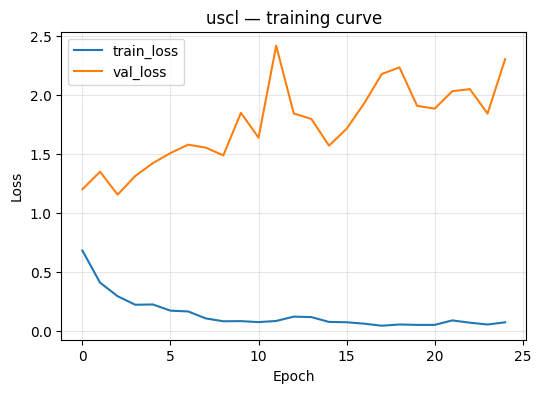

Backbone: uscl
Per-label AUROC: {'finding_b_lines': np.float64(0.8591016548463357), 'finding_consolidation': np.float64(0.8268560474032765), 'finding_pleural_effusion': np.float64(0.7439271255060729), 'finding_pleural_thickening': np.float64(0.7911205073995771)}

--- Fixed 0.5 threshold (what we reported before) ---
finding_b_lines: F1=0.610
finding_consolidation: F1=0.547
finding_pleural_effusion: F1=0.262
finding_pleural_thickening: F1=0.648

--- Per-class tuned threshold ---
finding_b_lines: best_threshold=0.50 F1=0.610
finding_consolidation: best_threshold=0.05 F1=0.711
finding_pleural_effusion: best_threshold=0.80 F1=0.340
finding_pleural_thickening: best_threshold=0.65 F1=0.656

Save these per-class thresholds alongside the model -- inference needs them, not a blanket 0.5.


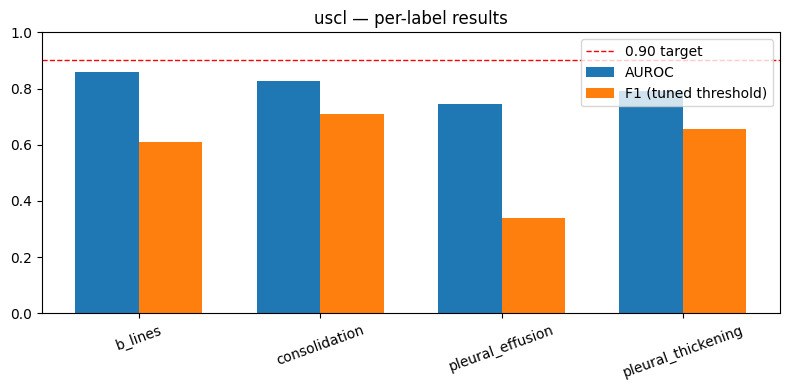

Saved results to /content/drive/MyDrive/POCUS-Project/Pulmonary/results_uscl.json

==================== imagenet ====================
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 147MB/s]


Backbone: imagenet | Trainable parameters: ['features.7.1.conv1.weight', 'features.7.1.bn1.weight', 'features.7.1.bn1.bias', 'features.7.1.conv2.weight', 'features.7.1.bn2.weight', 'features.7.1.bn2.bias', 'head.weight', 'head.bias']
pos_weight per label: {'finding_b_lines': np.float32(2.2229729), 'finding_consolidation': np.float32(2.0479233), 'finding_pleural_effusion': np.float32(5.9130435), 'finding_pleural_thickening': np.float32(4.514451)}
[imagenet] Epoch 01/25 | train_loss=0.5403 val_loss=1.6028 | finding_b_lines=0.880, finding_consolidation=0.836, finding_pleural_effusion=0.829, finding_pleural_thickening=0.689
[imagenet] Epoch 02/25 | train_loss=0.2309 val_loss=1.8649 | finding_b_lines=0.917, finding_consolidation=0.777, finding_pleural_effusion=0.890, finding_pleural_thickening=0.657
[imagenet] Epoch 03/25 | train_loss=0.1596 val_loss=2.1797 | finding_b_lines=0.825, finding_consolidation=0.782, finding_pleural_effusion=0.890, finding_pleural_thickening=0.700
[imagenet] Epoch

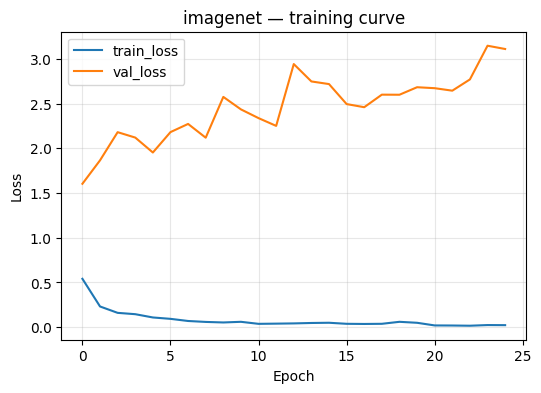

Backbone: imagenet
Per-label AUROC: {'finding_b_lines': np.float64(0.8801418439716312), 'finding_consolidation': np.float64(0.8355698849773442), 'finding_pleural_effusion': np.float64(0.8292004048582997), 'finding_pleural_thickening': np.float64(0.6889006342494715)}

--- Fixed 0.5 threshold (what we reported before) ---
finding_b_lines: F1=0.600
finding_consolidation: F1=0.731
finding_pleural_effusion: F1=0.337
finding_pleural_thickening: F1=0.512

--- Per-class tuned threshold ---
finding_b_lines: best_threshold=0.85 F1=0.629
finding_consolidation: best_threshold=0.50 F1=0.731
finding_pleural_effusion: best_threshold=0.85 F1=0.414
finding_pleural_thickening: best_threshold=0.60 F1=0.582

Save these per-class thresholds alongside the model -- inference needs them, not a blanket 0.5.


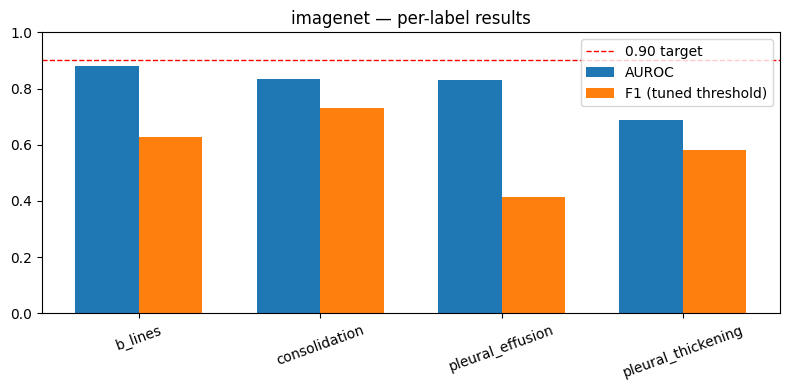

Saved results to /content/drive/MyDrive/POCUS-Project/Pulmonary/results_imagenet.json

==================== usfm ====================


Downloading...
From (original): https://drive.google.com/uc?id=1KRwXZgYterH895Z8EpXpR1L1eSMMJo4q
From (redirected): https://drive.google.com/uc?id=1KRwXZgYterH895Z8EpXpR1L1eSMMJo4q&confirm=t&uuid=05bc3091-27b5-41bb-939e-715d55bb6f50
To: /content/drive/MyDrive/POCUS-Project/Pulmonary/USFM_weights/USFM_latest.pth
100%|██████████| 343M/343M [00:12<00:00, 27.6MB/s] 
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Missing keys: ['blocks.0.attn.relative_position_index', 'blocks.1.attn.relative_position_index', 'blocks.2.attn.relative_position_index', 'blocks.3.attn.relative_position_index', 'blocks.4.attn.relative_position_index', 'blocks.5.attn.relative_position_index', 'blocks.6.attn.relative_position_index', 'blocks.7.attn.relative_position_index', 'blocks.8.attn.relative_position_index', 'blocks.9.attn.relative_position_index', 'blocks.10.attn.relative_position_index', 'blocks.11.attn.relative_position_index', 'fc_norm.weight', 'fc_norm.bias']
Unexpected keys: ['mask_token', 'norm.weight', 'norm.bias']
Backbone: usfm | Trainable parameters: ['features.vit.blocks.11.gamma_1', 'features.vit.blocks.11.gamma_2', 'features.vit.blocks.11.norm1.weight', 'features.vit.blocks.11.norm1.bias', 'features.vit.blocks.11.attn.q_bias', 'features.vit.blocks.11.attn.v_bias', 'features.vit.blocks.11.attn.relative_position_bias_table', 'features.vit.blocks.11.attn.qkv.weight', 'features.vit.blocks.11.attn.proj.w

NameError: name 'F' is not defined

In [18]:
BACKBONES_TO_RUN = ['uscl', 'imagenet', 'usfm']
all_results = {}
for backbone_name in BACKBONES_TO_RUN:
    print(f'\n{"="*20} {backbone_name} {"="*20}')
    train_loader, val_loader = build_dataloaders(backbone_name)
    model = build_model(backbone_name)
    ckpt_path = train_model(model, backbone_name, train_loader, val_loader)
    all_results[backbone_name] = evaluate_model(model, backbone_name, ckpt_path, val_loader)


## 10. Compare all three candidates

Uses `all_results` from the loop above. If you only ran a subset this session (e.g. you edited
`BACKBONES_TO_RUN` to just one), it fills in the rest from each backbone's saved
`results_{backbone}.json` if that file exists from an earlier run.


In [ ]:
for b in ['uscl', 'imagenet', 'usfm']:
    if b not in all_results:
        path = DRIVE_ROOT / 'Pulmonary' / f'results_{b}.json'
        if path.exists():
            all_results[b] = json.load(open(path))
        else:
            print(f'{b}: not run yet (no {path.name} found)')

if len(all_results) < 2:
    print('\nNeed at least 2 backbones run to compare -- go run the others first.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    x = np.arange(len(FINDING_COLS))
    width = 0.8 / len(all_results)

    for metric, ax, title in [('auroc', axes[0], 'AUROC'), ('f1_tuned', axes[1], 'F1 (tuned threshold)')]:
        for i, (b, res) in enumerate(all_results.items()):
            values = [res[metric][n] for n in FINDING_COLS]
            ax.bar(x + i * width, values, width, label=b)
        ax.set_xticks(x + width * (len(all_results) - 1) / 2)
        ax.set_xticklabels([n.replace('finding_', '') for n in FINDING_COLS], rotation=20)
        ax.set_ylim(0, 1)
        ax.axhline(0.9, color='red', linestyle='--', linewidth=1)
        ax.set_title(title)
        ax.legend()
    plt.tight_layout()
    plt.show()

    print('\nWinner per label (by F1):')
    for i, name in enumerate(FINDING_COLS):
        best_b = max(all_results, key=lambda b: all_results[b]['f1_tuned'][name])
        print(f'  {name}: {best_b} (F1={all_results[best_b]["f1_tuned"][name]:.3f})')


: 